In [3]:
%pip install "xlrd>=2.0.1"

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [5]:
file_path = Path("../dataset/superstore_sales_dataset.xls")

In [6]:
excel_file = pd.ExcelFile(file_path)

In [7]:
excel_file.sheet_names

['Orders', 'People', 'Returns']

In [8]:
df = pd.read_excel(
    file_path,
    sheet_name="Orders"
)

In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [10]:
df.shape

(10194, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

# Data Validation

In [12]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df[df.duplicated(keep=False)].head(20)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [15]:
df[
    ["Sales", "Quantity", "Discount", "Profit"]
].describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


In [16]:
(df["Sales"] <= 0).sum()

np.int64(0)

In [17]:
(df["Quantity"] <= 0).sum()

np.int64(0)

In [18]:
(df["Discount"] < 0).sum()

np.int64(0)

In [19]:
(df["Discount"] > 1).sum()

np.int64(0)

In [20]:
(df["Profit"] < 0).sum()

np.int64(1901)

In [21]:
(df["Profit"] < 0).sum()

np.int64(1901)

In [22]:
(df["Ship Date"] < df["Order Date"]).sum()

np.int64(0)

In [23]:
print("Unique Orders:", df["Order ID"].nunique())
print("Unique Customers:", df["Customer ID"].nunique())
print("Unique Products:", df["Product ID"].nunique())
print("Unique Categories:", df["Category"].nunique())
print("Unique Sub-Categories:", df["Sub-Category"].nunique())
print("Unique Regions:", df["Region"].nunique())
print("Unique States:", df["State/Province"].nunique())

Unique Orders: 5111
Unique Customers: 804
Unique Products: 1862
Unique Categories: 3
Unique Sub-Categories: 17
Unique Regions: 4
Unique States: 59


In [24]:
df["Category"].value_counts()

Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

In [25]:
df["Segment"].value_counts()

Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64

In [26]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Sales: $2,326,534.35
Total Profit: $292,296.81
Profit Margin: 12.56%


In [27]:
print(f"Total Quantity: {df['Quantity'].sum():,}")

Total Quantity: 38,654


In [28]:
aov = total_sales / df["Order ID"].nunique()

print(f"Average Order Value: ${aov:,.2f}")

Average Order Value: $455.20


In [29]:
df_clean = df.copy()

In [30]:
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

# Feature Engineering

In [31]:
df_clean["Shipping Days"] = (
    df_clean["Ship Date"] - df_clean["Order Date"]
).dt.days

In [32]:
df_clean["Shipping Days"].describe()

count    10194.000000
mean         3.961350
std          1.742829
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         11.000000
Name: Shipping Days, dtype: float64

In [33]:
df_clean["Order Year"] = df_clean["Order Date"].dt.year

In [34]:
df_clean["Order Month"] = df_clean["Order Date"].dt.month

In [35]:
df_clean["Month Name"] = (
    df_clean["Order Date"].dt.month_name()
)

In [36]:
df_clean["Year-Month"] = (
    df_clean["Order Date"]
    .dt.to_period("M")
    .astype(str)
)

In [37]:
df_clean["Order Day"] = (
    df_clean["Order Date"].dt.day_name()
)

# Profit Margin per Transaction

In [38]:
df_clean["Profit Margin"] = (
    df_clean["Profit"] / df_clean["Sales"]
) * 100

In [39]:
df_clean[
    ["Sales", "Profit", "Discount", "Profit Margin"]
].head()

,Sales,Profit,Discount,Profit Margin
0,16.448,5.5512,0.2,33.75
1,3.540,-5.4870,0.8,-155.00
2,11.784,4.2717,0.2,36.25
3,272.736,-64.7748,0.2,-23.75
4,19.536,4.8840,0.2,25.00


In [40]:
def discount_band(discount):
    if discount == 0:
        return "No Discount"
    elif discount <= 0.20:
        return "Low Discount"
    elif discount <= 0.40:
        return "Medium Discount"
    else:
        return "High Discount"

In [41]:
df_clean["Discount Band"] = (
    df_clean["Discount"]
    .apply(discount_band)
)

In [42]:
df_clean["Discount Band"].value_counts()

Discount Band
No Discount        4925
Low Discount       3854
High Discount       951
Medium Discount     464
Name: count, dtype: int64

# Profitability by Discount

In [43]:
discount_analysis = (
    df_clean.groupby("Discount Band")
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

In [44]:
discount_analysis["Profit Margin"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"] * 100
).round(2)

In [45]:
discount_analysis.sort_values(
    "Profit Margin",
    ascending=False
)

,Orders,Sales,Profit,Quantity,Profit Margin
Discount Band,,,,,
No Discount,2714,1.105324e+06,326718.5872,18770,29.56
Low Discount,2541,8.564504e+05,101598.9132,14431,11.86
Medium Discount,404,2.354653e+05,-35990.9575,1749,-15.29
High Discount,753,1.292949e+05,-100029.7283,3704,-77.37


# Category Profitability

In [46]:
category_analysis = (
    df_clean.groupby("Category")
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

In [47]:
category_analysis["Profit Margin"] = (
    category_analysis["Profit"] /
    category_analysis["Sales"] * 100
).round(2)

In [48]:
category_analysis.sort_values(
    "Profit",
    ascending=False
)

,Orders,Sales,Profit,Quantity,Profit Margin
Category,,,,,
Technology,1560,839893.2790,146543.3756,7017,17.45
Office Supplies,3812,731893.3140,126023.4434,23268,17.22
Furniture,1819,754747.7613,19729.9956,8369,2.61


# Sub-Category Profitability

In [49]:
subcategory_analysis = (
    df_clean.groupby("Sub-Category")
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

In [50]:
subcategory_analysis["Profit Margin"] = (
    subcategory_analysis["Profit"] /
    subcategory_analysis["Sales"] * 100
).round(2)

In [51]:
subcategory_analysis.sort_values(
    "Profit",
    ascending=False
)

,Orders,Sales,Profit,Quantity,Profit Margin
Sub-Category,,,,,
Copiers,70,150745.2900,56093.9365,242,37.21
Phones,826,331842.6400,45050.8265,3357,13.58
Accessories,718,167380.3180,41936.6357,2976,25.05
Paper,1205,79540.5380,34511.5070,5207,43.39
Binders,1339,207354.8810,31426.1003,6071,15.16
Chairs,591,335768.2490,27223.5323,2431,8.11
Storage,787,224644.5540,21285.1115,3191,9.48
Appliances,459,108213.1850,18329.4844,1750,16.94
Furnishings,919,95598.1260,13891.7430,3799,14.53


In [52]:
subcategory_analysis[
    subcategory_analysis["Profit"] < 0
].sort_values("Profit")

,Orders,Sales,Profit,Quantity,Profit Margin
Sub-Category,,,,,
Tables,314,208020.1820,-17753.2061,1261,-8.53
Bookcases,228,115361.2043,-3632.0736,878,-3.15
Supplies,189,46725.4980,-1171.3945,653,-2.51


# Regional Profitability

In [53]:
region_analysis = (
    df_clean.groupby("Region")
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

In [54]:
region_analysis["Profit Margin"] = (
    region_analysis["Profit"] /
    region_analysis["Sales"] * 100
).round(2)

In [55]:
region_analysis.sort_values(
    "Profit",
    ascending=False
)

,Orders,Sales,Profit,Quantity,Profit Margin
Region,,,,,
West,1635,739813.6085,110798.8170,12466,14.98
East,1475,691828.1680,94883.2603,11159,13.71
South,822,391721.9050,46749.4303,6209,11.93
Central,1179,503170.6728,39865.3070,8820,7.92


# Customer Profitability

In [56]:
customer_analysis = (
    df_clean.groupby(
        ["Customer ID", "Customer Name"]
    )
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

In [57]:
customer_analysis["Profit Margin"] = (
    customer_analysis["Profit"] /
    customer_analysis["Sales"] * 100
).round(2)

In [58]:
customer_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,,Orders,Sales,Profit,Quantity,Profit Margin
Customer ID,Customer Name,,,,,
TC-20980,Tamara Chand,5,19052.218,8981.3239,42,47.14
RB-19360,Raymond Buch,6,15117.339,6976.0959,71,46.15
SC-20095,Sanjit Chand,9,14142.334,5757.4119,87,40.71
HL-15040,Hunter Lopez,6,12873.298,5622.4292,50,43.68
AB-10105,Adrian Barton,10,14473.571,5444.8055,73,37.62
TA-21385,Tom Ashbrook,4,14595.620,4703.7883,36,32.23
CM-12385,Christopher Martinez,4,8954.020,3899.8904,34,43.55
KD-16495,Keith Dawkins,12,8181.256,3038.6254,84,37.14
AR-10540,Andy Reiter,6,6608.448,2884.6208,33,43.65


In [59]:
discount_analysis

,Orders,Sales,Profit,Quantity,Profit Margin
Discount Band,,,,,
High Discount,753,1.292949e+05,-100029.7283,3704,-77.37
Low Discount,2541,8.564504e+05,101598.9132,14431,11.86
Medium Discount,404,2.354653e+05,-35990.9575,1749,-15.29
No Discount,2714,1.105324e+06,326718.5872,18770,29.56


In [60]:
category_analysis

,Orders,Sales,Profit,Quantity,Profit Margin
Category,,,,,
Furniture,1819,754747.7613,19729.9956,8369,2.61
Office Supplies,3812,731893.3140,126023.4434,23268,17.22
Technology,1560,839893.2790,146543.3756,7017,17.45


In [61]:
subcategory_analysis

,Orders,Sales,Profit,Quantity,Profit Margin
Sub-Category,,,,,
Accessories,718,167380.3180,41936.6357,2976,25.05
Appliances,459,108213.1850,18329.4844,1750,16.94
Art,756,27659.0140,6653.1962,3092,24.05
Binders,1339,207354.8810,31426.1003,6071,15.16
Bookcases,228,115361.2043,-3632.0736,878,-3.15
Chairs,591,335768.2490,27223.5323,2431,8.11
Copiers,70,150745.2900,56093.9365,242,37.21
Envelopes,251,16528.3620,6988.0247,914,42.28
Fasteners,226,8532.2400,2428.6358,980,28.46


# Deep Discount vs Profitability Analysis

In [62]:
def discount_band(discount):
    if discount == 0:
        return "No Discount"
    elif discount <= 0.20:
        return "Low Discount"
    elif discount <= 0.40:
        return "Medium Discount"
    else:
        return "High Discount"


df_clean["Discount Band"] = (
    df_clean["Discount"]
    .apply(discount_band)
)

In [63]:
df_clean["Discount Band"].value_counts()

Discount Band
No Discount        4925
Low Discount       3854
High Discount       951
Medium Discount     464
Name: count, dtype: int64

In [64]:
loss_by_discount = (
    df_clean.groupby("Discount Band")
    .agg(
        Transactions=("Row ID", "count"),
        Loss_Transactions=("Profit", lambda x: (x < 0).sum()),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

loss_by_discount["Loss Rate %"] = (
    loss_by_discount["Loss_Transactions"] /
    loss_by_discount["Transactions"] * 100
).round(2)

loss_by_discount

,Transactions,Loss_Transactions,Sales,Profit,Loss Rate %
Discount Band,,,,,
High Discount,951,951,1.292949e+05,-100029.7283,100.00
Low Discount,3854,531,8.564504e+05,101598.9132,13.78
Medium Discount,464,419,2.354653e+05,-35990.9575,90.30
No Discount,4925,0,1.105324e+06,326718.5872,0.00


In [65]:
exact_discount_analysis = (
    df_clean.groupby("Discount")
    .agg(
        Transactions=("Row ID", "count"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

exact_discount_analysis["Profit Margin %"] = (
    exact_discount_analysis["Profit"] /
    exact_discount_analysis["Sales"] * 100
).round(2)

exact_discount_analysis

,Transactions,Sales,Profit,Profit Margin %
Discount,,,,
0.00,4925,1.105324e+06,326718.5872,29.56
0.10,96,5.495250e+04,9099.9700,16.56
0.15,52,2.755852e+04,1418.9915,5.15
0.20,3706,7.739394e+05,91079.9517,11.77
0.30,230,1.044741e+05,-10513.4456,-10.06
0.32,27,1.449346e+04,-2391.1377,-16.50
0.40,207,1.164978e+05,-23086.3742,-19.82
0.45,11,5.484974e+03,-2493.1111,-45.45
0.50,66,5.891854e+04,-20506.4281,-34.80


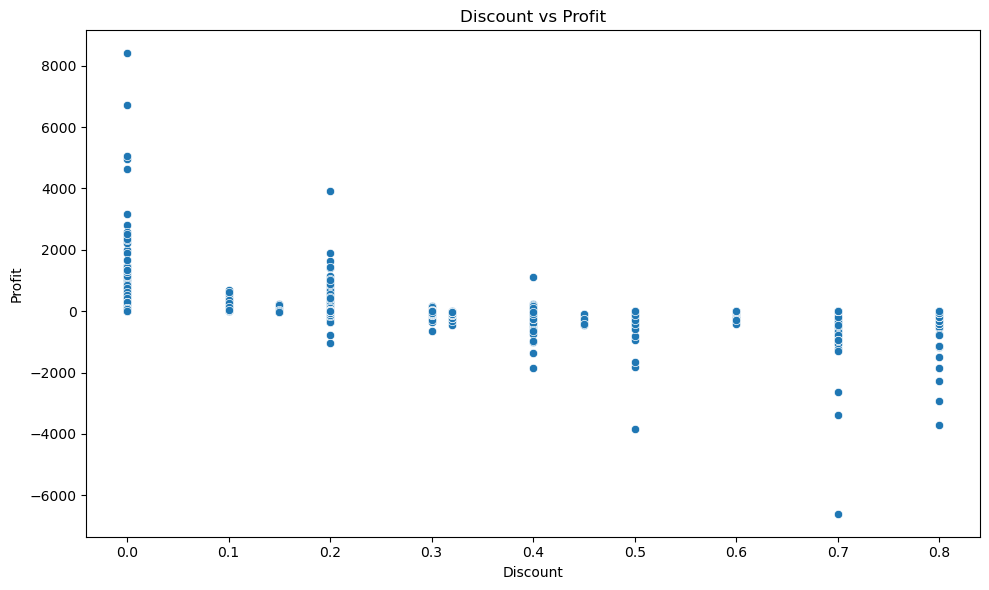

In [66]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [67]:
category_discount = (
    df_clean.groupby(["Category", "Discount Band"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Row ID", "count")
    )
)

category_discount["Profit Margin %"] = (
    category_discount["Profit"] /
    category_discount["Sales"] * 100
).round(2)

category_discount

Sales       Profit  Transactions  \
Category        Discount Band                                             
Furniture       High Discount     36124.3940  -25590.9243           229   
                Low Discount     298169.2625   15209.2941           766   
                Medium Discount  160299.0448  -29365.3614           326   
                No Discount      260155.0600   59476.9872           880   
Office Supplies High Discount     39633.8930  -47224.2558           687   
                Low Discount     239242.2550   39437.7823          2241   
                Medium Discount     606.5560     -81.9820             2   
                No Discount      452410.6100  133891.8989          3198   
Technology      High Discount     53536.5790  -27214.5482            35   
                Low Discount     319038.8970   46951.8368           847   
                Medium Discount   74559.6830   -6543.6141           136   
                No Discount      392758.1200  133349.7011           847   

                                 Profit Margin %  
Category        Discount Band                     
Furniture       High Discount             -70.84  
                Low Discount                5.10  
                Medium Discount           -18.32  
                No Discount                22.86  
Office Supplies High Discount            -119.15  
                Low Discount               16.48  
                Medium Discount           -13.52  
                No Discount                29.60  
Technology      High Discount             -50.83  
                Low Discount               14.72  
                Medium Discount            -8.78  
                No Discount                33.95

In [68]:
subcategory_analysis.sort_values(
    "Profit",
    ascending=True
).head(10)

,Orders,Sales,Profit,Quantity,Profit Margin
Sub-Category,,,,,
Tables,314,208020.1820,-17753.2061,1261,-8.53
Bookcases,228,115361.2043,-3632.0736,878,-3.15
Supplies,189,46725.4980,-1171.3945,653,-2.51
Fasteners,226,8532.2400,2428.6358,980,28.46
Machines,114,189925.0310,3461.9769,442,1.82
Labels,348,12695.0420,5572.7780,1410,43.90
Art,756,27659.0140,6653.1962,3092,24.05
Envelopes,251,16528.3620,6988.0247,914,42.28
Furnishings,919,95598.1260,13891.7430,3799,14.53


In [69]:
subcategory_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,Orders,Sales,Profit,Quantity,Profit Margin
Sub-Category,,,,,
Copiers,70,150745.290,56093.9365,242,37.21
Phones,826,331842.640,45050.8265,3357,13.58
Accessories,718,167380.318,41936.6357,2976,25.05
Paper,1205,79540.538,34511.5070,5207,43.39
Binders,1339,207354.881,31426.1003,6071,15.16
Chairs,591,335768.249,27223.5323,2431,8.11
Storage,787,224644.554,21285.1115,3191,9.48
Appliances,459,108213.185,18329.4844,1750,16.94
Furnishings,919,95598.126,13891.7430,3799,14.53


In [70]:
loss_subcategories = (
    subcategory_analysis[
        subcategory_analysis["Profit"] < 0
    ]
)

print(
    "Loss-making sub-categories:",
    len(loss_subcategories)
)

Loss-making sub-categories: 3


In [71]:
region_analysis = (
    df_clean.groupby("Region")
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

region_analysis["Profit Margin %"] = (
    region_analysis["Profit"] /
    region_analysis["Sales"] * 100
).round(2)

region_analysis.sort_values(
    "Profit",
    ascending=False
)

,Orders,Sales,Profit,Quantity,Profit Margin %
Region,,,,,
West,1635,739813.6085,110798.8170,12466,14.98
East,1475,691828.1680,94883.2603,11159,13.71
South,822,391721.9050,46749.4303,6209,11.93
Central,1179,503170.6728,39865.3070,8820,7.92


In [72]:
output_path = Path(
    "../dataset/superstore_sales_clean.csv"
)

df_clean.to_csv(
    output_path,
    index=False
)

print(f"Saved: {output_path}")

Saved: ..\dataset\superstore_sales_clean.csv


In [73]:
output_path.exists()

True

# Customer Profitability Analysis

In [74]:
customer_analysis = (
    df_clean.groupby(
        ["Customer ID", "Customer Name"]
    )
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

customer_analysis["Profit Margin %"] = (
    customer_analysis["Profit"] /
    customer_analysis["Sales"] * 100
).round(2)

In [75]:
customer_analysis.head()

,,Orders,Sales,Profit,Quantity,Profit Margin %
Customer ID,Customer Name,,,,,
AA-10315,Alex Avila,5,5563.560,-362.8825,30,-6.52
AA-10375,Allen Armold,9,1056.390,277.3824,41,26.26
AA-10480,Andrew Allen,4,1790.512,435.8274,36,24.34
AA-10645,Anna Andreadi,6,5086.935,857.8033,64,16.86
AB-10015,Aaron Bergman,3,886.156,129.3465,13,14.60


In [76]:
top_customers_sales = (
    customer_analysis
    .sort_values("Sales", ascending=False)
    .head(10)
)

top_customers_sales

,,Orders,Sales,Profit,Quantity,Profit Margin %
Customer ID,Customer Name,,,,,
SM-20320,Sean Miller,5,25043.050,-1980.7393,50,-7.91
TC-20980,Tamara Chand,5,19052.218,8981.3239,42,47.14
RB-19360,Raymond Buch,6,15117.339,6976.0959,71,46.15
TA-21385,Tom Ashbrook,4,14595.620,4703.7883,36,32.23
AB-10105,Adrian Barton,10,14473.571,5444.8055,73,37.62
KL-16645,Ken Lonsdale,12,14175.229,806.8550,113,5.69
SC-20095,Sanjit Chand,9,14142.334,5757.4119,87,40.71
HL-15040,Hunter Lopez,6,12873.298,5622.4292,50,43.68
SE-20110,Sanjit Engle,11,12209.438,2650.6769,78,21.71


In [77]:
top_customers_profit = (
    customer_analysis
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_customers_profit

,,Orders,Sales,Profit,Quantity,Profit Margin %
Customer ID,Customer Name,,,,,
TC-20980,Tamara Chand,5,19052.218,8981.3239,42,47.14
RB-19360,Raymond Buch,6,15117.339,6976.0959,71,46.15
SC-20095,Sanjit Chand,9,14142.334,5757.4119,87,40.71
HL-15040,Hunter Lopez,6,12873.298,5622.4292,50,43.68
AB-10105,Adrian Barton,10,14473.571,5444.8055,73,37.62
TA-21385,Tom Ashbrook,4,14595.620,4703.7883,36,32.23
CM-12385,Christopher Martinez,4,8954.020,3899.8904,34,43.55
KD-16495,Keith Dawkins,12,8181.256,3038.6254,84,37.14
AR-10540,Andy Reiter,6,6608.448,2884.6208,33,43.65


In [78]:
loss_making_customers = (
    customer_analysis[
        customer_analysis["Profit"] < 0
    ]
    .sort_values("Profit")
)

loss_making_customers.head(20)

,,Orders,Sales,Profit,Quantity,Profit Margin %
Customer ID,Customer Name,,,,,
CS-12505,Cindy Stewart,6,5690.0550,-6626.3895,40,-116.46
GT-14635,Grant Thornton,3,9351.2120,-4108.6589,26,-43.94
LF-17185,Luke Foster,7,3930.5090,-3583.9770,69,-91.18
SR-20425,Sharelle Roach,5,3233.4810,-3333.9144,34,-103.11
HG-14965,Henry Goldwyn,12,3247.6420,-2797.9635,68,-86.15
NC-18415,Nathan Cano,6,2218.9900,-2204.8072,38,-99.36
SB-20290,Sean Braxton,7,8057.8910,-2082.7451,84,-25.85
SM-20320,Sean Miller,5,25043.0500,-1980.7393,50,-7.91
CP-12340,Christine Phan,8,5888.2750,-1850.3029,59,-31.42


In [79]:
print(
    "Loss-making customers:",
    len(loss_making_customers)
)

Loss-making customers: 159


In [80]:
product_analysis = (
    df_clean.groupby(
        ["Product ID", "Product Name"]
    )
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

In [81]:
product_analysis["Profit Margin %"] = (
    product_analysis["Profit"] /
    product_analysis["Sales"] * 100
).round(2)

In [82]:
product_analysis.sort_values(
    "Sales",
    ascending=False
).head(10)

,,Orders,Sales,Profit,Quantity,Profit Margin %
Product ID,Product Name,,,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,5,61599.824,2.519993e+04,20,40.91
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,10,27453.384,7.753039e+03,31,28.24
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,1,22638.480,-1.811078e+03,6,-8.00
FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,8,21870.576,3.410605e-13,39,0.00
OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,11,19823.479,2.233505e+03,37,11.27
OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,9,19024.500,7.609800e+02,48,4.00
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,8,18839.686,6.983884e+03,38,37.07
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",3,18374.895,4.094977e+03,12,22.29
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,6,17965.068,-1.878166e+03,27,-10.45


In [83]:
product_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,,Orders,Sales,Profit,Quantity,Profit Margin %
Product ID,Product Name,,,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,5,61599.824,25199.9280,20,40.91
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,10,27453.384,7753.0390,31,28.24
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,8,18839.686,6983.8836,38,37.07
TEC-CO-10003763,Canon PC1060 Personal Laser Copier,4,11619.834,4570.9347,19,39.34
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",3,18374.895,4094.9766,12,22.29
TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,2,7699.890,3772.9461,11,49.00
TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",2,14299.890,3717.9714,11,26.00
TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless Headset System,7,9367.290,3696.2820,24,39.46
OFF-BI-10001120,Ibico EPK-21 Electric Binding System,3,15875.916,3345.2823,13,21.07


In [84]:
product_analysis.sort_values(
    "Profit",
    ascending=True
).head(10)

,,Orders,Sales,Profit,Quantity,Profit Margin %
Product ID,Product Name,,,,,
TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,3,11099.963,-8879.9704,9,-80.00
TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,4,16829.901,-4589.9730,18,-27.27
TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,1,7999.980,-3839.9904,4,-48.00
FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,5,9917.640,-2876.1156,27,-29.00
FUR-TA-10001889,Bush Advantage Collection Racetrack Conference Table,7,9544.725,-1934.3976,33,-20.27
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,6,17965.068,-1878.1662,27,-10.45
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,1,22638.480,-1811.0784,6,-8.00
OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Opener,6,16656.200,-1299.1836,22,-7.80
FUR-TA-10001950,Balt Solid Wood Round Tables,4,6518.754,-1201.0581,19,-18.42


In [85]:
loss_making_products = product_analysis[
    product_analysis["Profit"] < 0
].sort_values("Profit")

print(
    "Loss-making products:",
    len(loss_making_products)
)

Loss-making products: 306


In [86]:
monthly_analysis = (
    df_clean.groupby("Year-Month")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    )
)

In [87]:
monthly_analysis["Profit Margin %"] = (
    monthly_analysis["Profit"] /
    monthly_analysis["Sales"] * 100
).round(2)

In [88]:
monthly_analysis

,Sales,Profit,Quantity,Orders,Profit Margin %
Year-Month,,,,,
2023-01,14518.0550,2539.3907,306,33,17.49
2023-02,4519.8920,862.3084,159,28,19.08
2023-03,56933.9090,693.4499,597,72,1.22
2023-04,28295.3450,3488.8352,536,66,12.33
2023-05,26319.7670,3196.3918,504,72,12.14
2023-06,34669.4796,4999.7594,524,67,14.42
2023-07,33946.3930,-841.4826,550,65,-2.48
2023-08,28918.3385,5765.2250,624,75,19.94
2023-09,82670.4288,8593.6302,1015,134,10.40


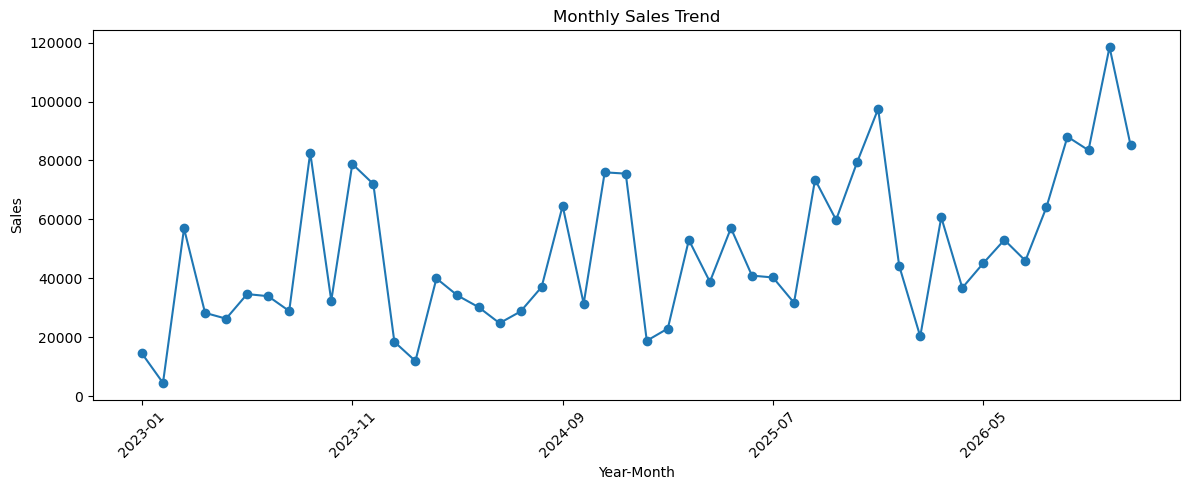

In [89]:
plt.figure(figsize=(12, 5))

monthly_analysis["Sales"].plot(
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

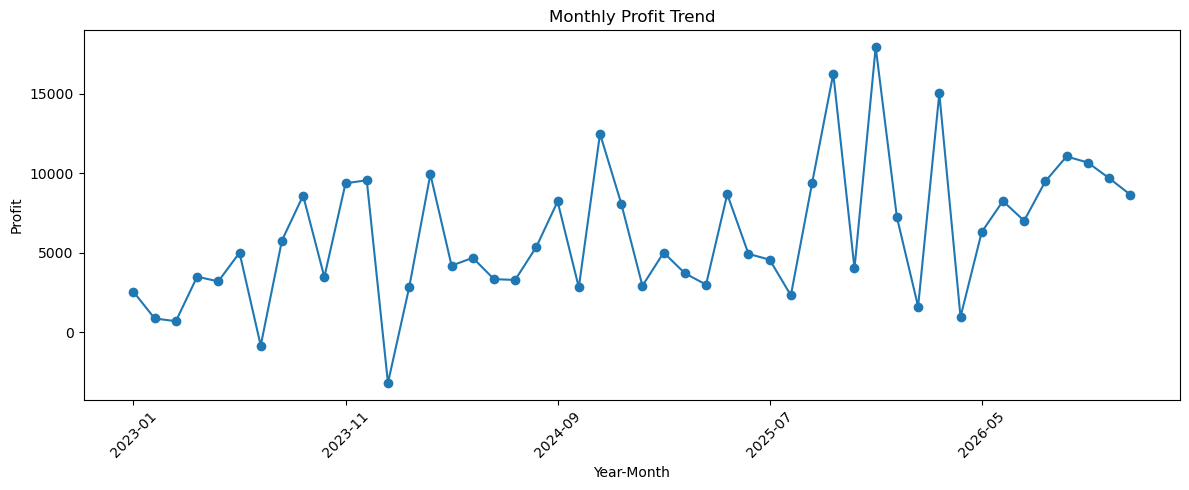

In [90]:
plt.figure(figsize=(12, 5))

monthly_analysis["Profit"].plot(
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

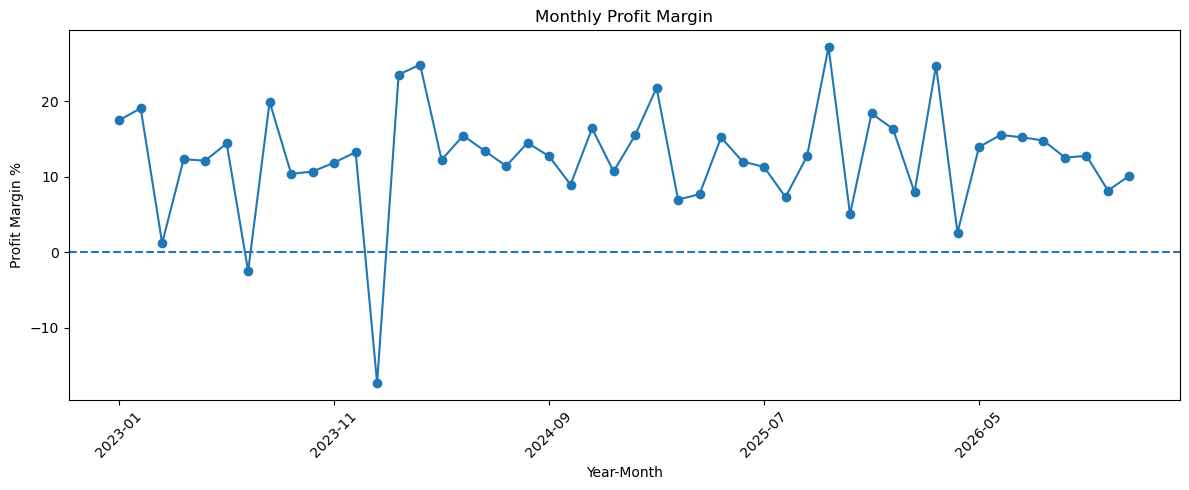

In [91]:
plt.figure(figsize=(12, 5))

monthly_analysis["Profit Margin %"].plot(
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Monthly Profit Margin")
plt.xlabel("Year-Month")
plt.ylabel("Profit Margin %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Shipping Performance

In [92]:
shipping_analysis = (
    df_clean["Shipping Days"]
    .describe()
)

shipping_analysis

count    10194.000000
mean         3.961350
std          1.742829
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         11.000000
Name: Shipping Days, dtype: float64

In [93]:
df_clean["Shipping Days"].value_counts().sort_index()

Shipping Days
0      523
1      369
2     1361
3     1025
4     2838
5     2243
6     1204
7      629
11       2
Name: count, dtype: int64

In [94]:
print(
    f"Average Shipping Time: "
    f"{df_clean['Shipping Days'].mean():.2f} days"
)

Average Shipping Time: 3.96 days


# Ship Mode Analysis

In [95]:
ship_mode_analysis = (
    df_clean.groupby("Ship Mode")
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Avg_Shipping_Days=("Shipping Days", "mean")
    )
)

In [96]:
ship_mode_analysis["Profit Margin %"] = (
    ship_mode_analysis["Profit"] /
    ship_mode_analysis["Sales"] * 100
).round(2)

In [97]:
ship_mode_analysis

,Orders,Sales,Profit,Quantity,Avg_Shipping_Days,Profit Margin %
Ship Mode,,,,,,
First Class,795,3.517507e+05,49012.7242,5724,2.182171,13.93
Same Day,266,1.292720e+05,16160.7480,1975,0.043876,12.50
Second Class,982,4.666711e+05,58962.1329,7546,3.237999,12.63
Standard Class,3068,1.378841e+06,168161.2095,23409,4.995425,12.20


In [98]:
output_path = Path(
    "../dataset/superstore_sales_clean.csv"
)

df_clean.to_csv(
    output_path,
    index=False
)

print(f"Saved: {output_path}")

Saved: ..\dataset\superstore_sales_clean.csv


In [99]:
output_path.exists()

True

# Customer Profitability

In [100]:
customer_analysis = (
    df_clean.groupby(
        ["Customer ID", "Customer Name"]
    )
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

customer_analysis["Profit Margin %"] = (
    customer_analysis["Profit"] /
    customer_analysis["Sales"] * 100
).round(2)

In [101]:
customer_analysis.sort_values(
    "Sales",
    ascending=False
).head(10)

,,Orders,Sales,Profit,Quantity,Profit Margin %
Customer ID,Customer Name,,,,,
SM-20320,Sean Miller,5,25043.050,-1980.7393,50,-7.91
TC-20980,Tamara Chand,5,19052.218,8981.3239,42,47.14
RB-19360,Raymond Buch,6,15117.339,6976.0959,71,46.15
TA-21385,Tom Ashbrook,4,14595.620,4703.7883,36,32.23
AB-10105,Adrian Barton,10,14473.571,5444.8055,73,37.62
KL-16645,Ken Lonsdale,12,14175.229,806.8550,113,5.69
SC-20095,Sanjit Chand,9,14142.334,5757.4119,87,40.71
HL-15040,Hunter Lopez,6,12873.298,5622.4292,50,43.68
SE-20110,Sanjit Engle,11,12209.438,2650.6769,78,21.71


In [102]:
customer_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,,Orders,Sales,Profit,Quantity,Profit Margin %
Customer ID,Customer Name,,,,,
TC-20980,Tamara Chand,5,19052.218,8981.3239,42,47.14
RB-19360,Raymond Buch,6,15117.339,6976.0959,71,46.15
SC-20095,Sanjit Chand,9,14142.334,5757.4119,87,40.71
HL-15040,Hunter Lopez,6,12873.298,5622.4292,50,43.68
AB-10105,Adrian Barton,10,14473.571,5444.8055,73,37.62
TA-21385,Tom Ashbrook,4,14595.620,4703.7883,36,32.23
CM-12385,Christopher Martinez,4,8954.020,3899.8904,34,43.55
KD-16495,Keith Dawkins,12,8181.256,3038.6254,84,37.14
AR-10540,Andy Reiter,6,6608.448,2884.6208,33,43.65


In [103]:
loss_making_customers = (
    customer_analysis[
        customer_analysis["Profit"] < 0
    ]
    .sort_values("Profit")
)

loss_making_customers.head(20)

,,Orders,Sales,Profit,Quantity,Profit Margin %
Customer ID,Customer Name,,,,,
CS-12505,Cindy Stewart,6,5690.0550,-6626.3895,40,-116.46
GT-14635,Grant Thornton,3,9351.2120,-4108.6589,26,-43.94
LF-17185,Luke Foster,7,3930.5090,-3583.9770,69,-91.18
SR-20425,Sharelle Roach,5,3233.4810,-3333.9144,34,-103.11
HG-14965,Henry Goldwyn,12,3247.6420,-2797.9635,68,-86.15
NC-18415,Nathan Cano,6,2218.9900,-2204.8072,38,-99.36
SB-20290,Sean Braxton,7,8057.8910,-2082.7451,84,-25.85
SM-20320,Sean Miller,5,25043.0500,-1980.7393,50,-7.91
CP-12340,Christine Phan,8,5888.2750,-1850.3029,59,-31.42


In [104]:
print(
    "Loss-making customers:",
    len(loss_making_customers)
)


Loss-making customers: 159


# Shipping & Ship Mode

In [105]:
shipping_analysis = df_clean["Shipping Days"].describe()

shipping_analysis

count    10194.000000
mean         3.961350
std          1.742829
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         11.000000
Name: Shipping Days, dtype: float64

In [106]:
print(
    f"Average Shipping Time: "
    f"{df_clean['Shipping Days'].mean():.2f} days"
)

Average Shipping Time: 3.96 days


In [107]:
ship_mode_analysis = (
    df_clean.groupby("Ship Mode")
    .agg(
        Orders=("Order ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Avg_Shipping_Days=("Shipping Days", "mean")
    )
)

ship_mode_analysis["Profit Margin %"] = (
    ship_mode_analysis["Profit"] /
    ship_mode_analysis["Sales"] * 100
).round(2)

ship_mode_analysis

,Orders,Sales,Profit,Quantity,Avg_Shipping_Days,Profit Margin %
Ship Mode,,,,,,
First Class,795,3.517507e+05,49012.7242,5724,2.182171,13.93
Same Day,266,1.292720e+05,16160.7480,1975,0.043876,12.50
Second Class,982,4.666711e+05,58962.1329,7546,3.237999,12.63
Standard Class,3068,1.378841e+06,168161.2095,23409,4.995425,12.20


# Sales vs Profit

In [108]:
product_analysis["Sales_Rank"] = (
    product_analysis["Sales"]
    .rank(ascending=False)
)

product_analysis["Profit_Rank"] = (
    product_analysis["Profit"]
    .rank(ascending=False)
)

In [109]:
product_analysis[
    product_analysis["Sales"] > product_analysis["Sales"].median()
].sort_values(
    "Profit"
).head(10)

,,Orders,Sales,Profit,Quantity,Profit Margin %,Sales_Rank,Profit_Rank
Product ID,Product Name,,,,,,,
TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,3,11099.963,-8879.9704,9,-80.00,24.0,1894.0
TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,4,16829.901,-4589.9730,18,-27.27,11.0,1893.0
TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,1,7999.980,-3839.9904,4,-48.00,45.0,1892.0
FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,5,9917.640,-2876.1156,27,-29.00,30.0,1891.0
FUR-TA-10001889,Bush Advantage Collection Racetrack Conference Table,7,9544.725,-1934.3976,33,-20.27,32.0,1890.0
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,6,17965.068,-1878.1662,27,-10.45,9.0,1889.0
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,1,22638.480,-1811.0784,6,-8.00,3.0,1888.0
OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Opener,6,16656.200,-1299.1836,22,-7.80,12.0,1887.0
FUR-TA-10001950,Balt Solid Wood Round Tables,4,6518.754,-1201.0581,19,-18.42,73.0,1886.0


# Customer Sales vs Profit

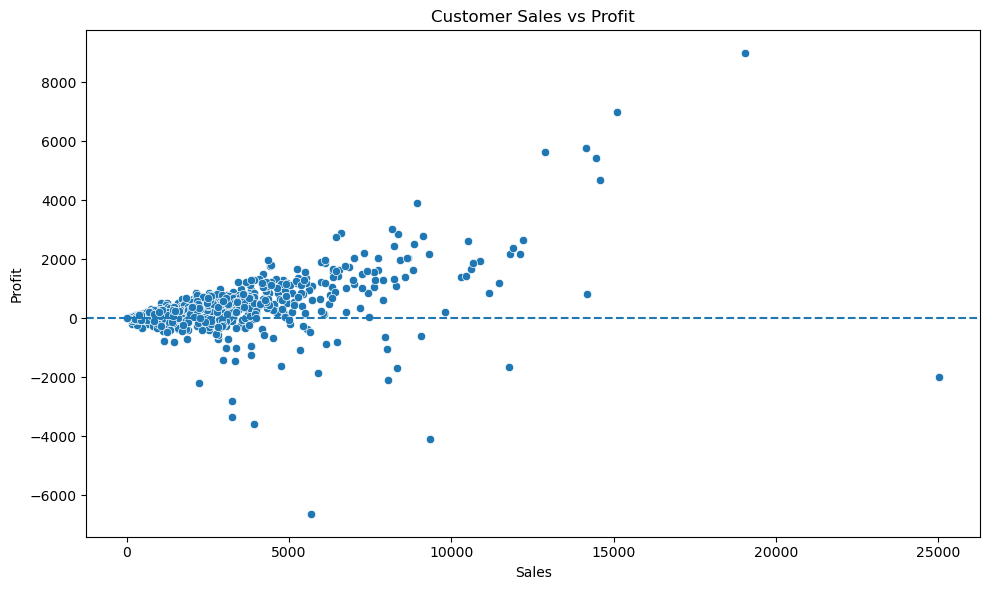

In [110]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_analysis,
    x="Sales",
    y="Profit"
)

plt.axhline(0, linestyle="--")

plt.title("Customer Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

# Product Sales vs Profit

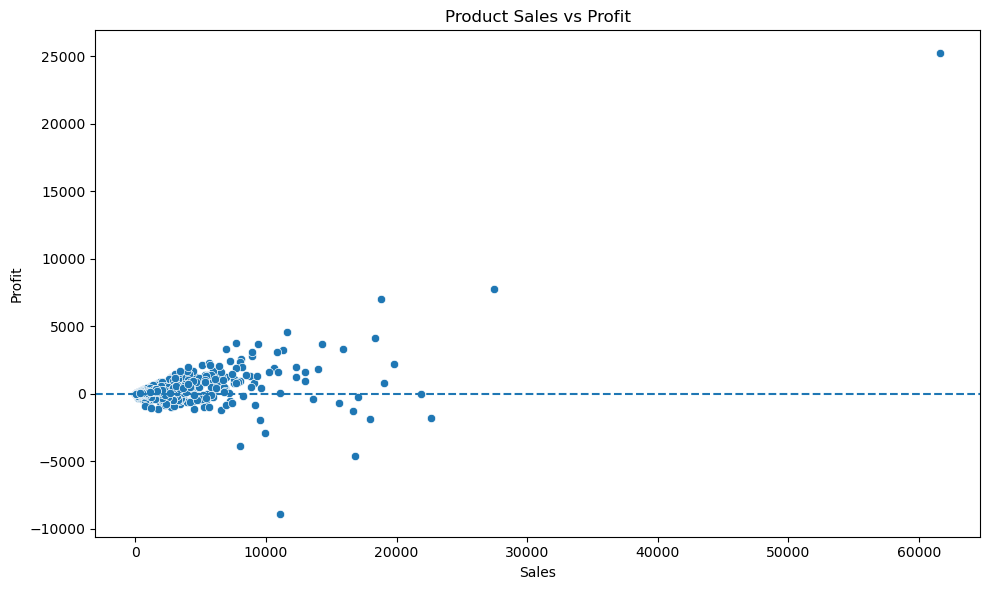

In [111]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_analysis,
    x="Sales",
    y="Profit"
)

plt.axhline(0, linestyle="--")

plt.title("Product Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

# Discount vs Profit

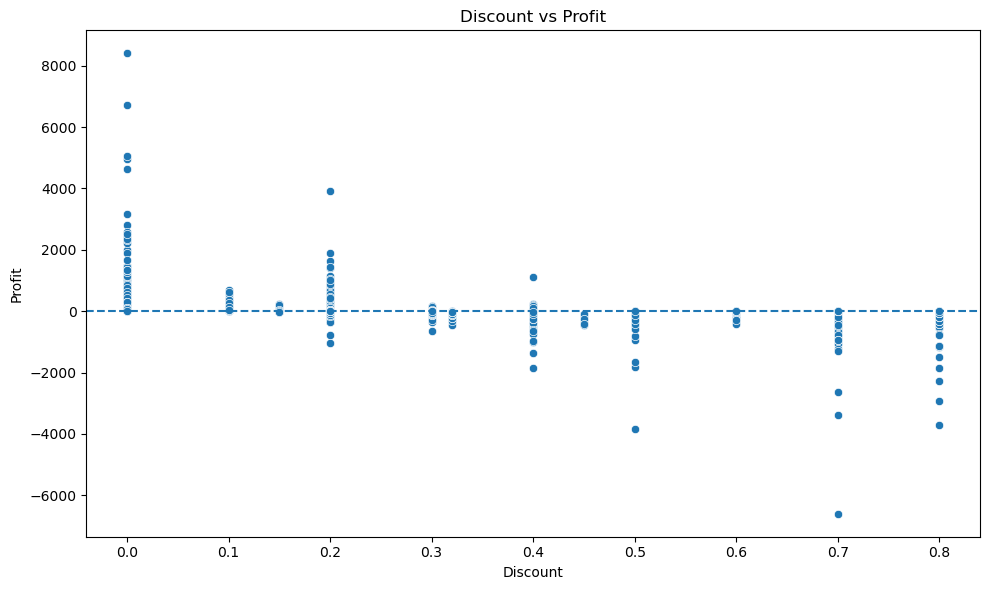

In [112]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="Discount",
    y="Profit"
)

plt.axhline(0, linestyle="--")

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

# Monthly Sales & Profit

In [113]:
monthly_analysis.sort_values(
    "Sales",
    ascending=False
).head(10)

,Sales,Profit,Quantity,Orders,Profit Margin %
Year-Month,,,,,
2026-11,118454.5050,9692.1037,1842,262,8.18
2025-12,97502.2770,17926.3013,1476,185,18.39
2026-09,88064.5320,11050.8024,1685,231,12.55
2026-12,85175.0328,8655.8269,1820,236,10.16
2026-10,83474.7832,10670.5312,1166,151,12.78
2023-09,82670.4288,8593.6302,1015,134,10.40
2025-11,79411.9658,4011.4075,1406,183,5.05
2023-11,78826.9567,9362.9557,1235,152,11.88
2024-11,75972.5635,12474.7884,1310,158,16.42


In [114]:
monthly_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,Sales,Profit,Quantity,Orders,Profit Margin %
Year-Month,,,,,
2025-12,97502.2770,17926.3013,1476,185,18.39
2025-10,59831.0010,16256.8422,770,107,27.17
2026-03,60728.4808,15013.0910,914,121,24.72
2024-11,75972.5635,12474.7884,1310,158,16.42
2026-09,88064.5320,11050.8024,1685,231,12.55
2026-10,83474.7832,10670.5312,1166,151,12.78
2024-03,39978.6280,9930.6134,528,81,24.84
2026-11,118454.5050,9692.1037,1842,262,8.18
2023-12,72008.3085,9554.6571,1158,150,13.27


In [115]:
monthly_analysis[
    monthly_analysis["Profit"] < 0
].sort_values("Profit")

,Sales,Profit,Quantity,Orders,Profit Margin %
Year-Month,,,,,
2024-01,18461.9156,-3189.8030,260,31,-17.28
2023-07,33946.3930,-841.4826,550,65,-2.48


In [116]:
Sales_kpis = {
    "Total Sales": df_clean["Sales"].sum(),
    "Total Profit": df_clean["Profit"].sum(),
    "Total Quantity": df_clean["Quantity"].sum(),
    "Total Orders": df_clean["Order ID"].nunique(),
    "Total Customers": df_clean["Customer ID"].nunique(),
    "Total Products": df_clean["Product ID"].nunique(),
    "Profit Margin %": (
        df_clean["Profit"].sum() /
        df_clean["Sales"].sum()
    ) * 100,
    "Average Order Value": (
        df_clean["Sales"].sum() /
        df_clean["Order ID"].nunique()
    ),
    "Average Shipping Days": df_clean["Shipping Days"].mean(),
    "Loss-Making Customers": (
        customer_analysis["Profit"] < 0
    ).sum()
}

Sales_kpis

{'Total Sales': np.float64(2326534.3543),
 'Total Profit': np.float64(292296.8145999999),
 'Total Quantity': np.int64(38654),
 'Total Orders': 5111,
 'Total Customers': 804,
 'Total Products': 1862,
 'Profit Margin %': np.float64(12.563614805849074),
 'Average Order Value': np.float64(455.2013997847779),
 'Average Shipping Days': np.float64(3.9613498136158523),
 'Loss-Making Customers': np.int64(159)}

In [117]:
output_path = Path(
    "../dataset/superstore_sales_clean.csv"
)

df_clean.to_csv(
    output_path,
    index=False
)

print(f"Saved to: {output_path}")

Saved to: ..\dataset\superstore_sales_clean.csv


In [118]:
output_path.exists()

True

In [119]:
import csv

In [120]:
# Create a PostgreSQL-safe copy
df_pg = df_clean.copy()

# Clean embedded line breaks from text columns
text_columns = df_pg.select_dtypes(include="object").columns

for col in text_columns:
    df_pg[col] = (
        df_pg[col]
        .astype(str)
        .str.replace(r"[\r\n]+", " ", regex=True)
        .str.strip()
    )

In [121]:
output_path = Path("../dataset/superstore_sales_clean.csv")

df_pg.to_csv(
    output_path,
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_MINIMAL,
    quotechar='"',
    doublequote=True,
    lineterminator="\n"
)

print(f"Saved: {output_path}")

Saved: ..\dataset\superstore_sales_clean.csv


In [126]:
df_test = pd.read_csv(
    output_path,
    encoding="utf-8"
)

df_test.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Discount,Profit,Shipping Days,Order Year,Order Month,Month Name,Year-Month,Order Day,Profit Margin,Discount Band
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,0.2,5.5512,4,2023,1,January,2023-01,Tuesday,33.75,Low Discount
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,0.8,-5.4870,4,2023,1,January,2023-01,Wednesday,-155.00,High Discount
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,0.2,4.2717,4,2023,1,January,2023-01,Wednesday,36.25,Low Discount
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,0.2,-64.7748,4,2023,1,January,2023-01,Wednesday,-23.75,Low Discount
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,0.2,4.8840,7,2023,1,January,2023-01,Thursday,25.00,Low Discount


In [127]:
pd.read_csv(
    output_path,
    encoding="utf-8"
).shape

(10194, 29)

In [128]:
print("Sales:", df_test["Sales"].sum())
print("Profit:", df_test["Profit"].sum())
print("Orders:", df_test["Order ID"].nunique())
print("Customers:", df_test["Customer ID"].nunique())

Sales: 2326534.3543
Profit: 292296.8145999999
Orders: 5111
Customers: 804
